<a href="https://colab.research.google.com/github/poojas49/Energy-Performance-Navigator/blob/feature%2FEDA_and_initial_ML_models/EnergyPerformanceNavigator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chicago Energy Performance Navigator**
---
**Team Members:**  
- Pooja Shinde – pshin8@uic.edu – [GitHub: poojas49]  
- Riya Mehta – rmeht43@uic.edu – [GitHub: riyagmehta]  
- Saakshi Patel – spate808@uic.edu – [GitHub: saakshipatel]  
- Heniben Prajapati – hpraj6@uic.edu – [GitHub: heni-29]  
- Het Nagda – hnagd@uic.edu – [GitHub: hetnagda20]
---
**GitHub Repository:** https://github.com/poojas49/Energy-Performance-Navigator

---
**Project Introduction**

The Chicago Energy Performance Navigator project aims to transform raw building energy benchmarking data into actionable insights for both building owners and city planners. Chicago's Energy Benchmarking Ordinance collects valuable building performance data, but currently fails to bridge the gap between data collection and meaningful action. Our analysis reveals that similar buildings can show energy consumption variations of up to 3-5 times, indicating significant untapped potential for efficiency improvements.

We are investigating how building characteristics, location, age, and energy sources correlate with energy efficiency metrics, and developing tools that can provide customized recommendations. By translating complex energy data into clear, actionable pathways, we aim to help building owners improve efficiency while enabling city planners to effectively target resources and policies to reduce Chicago's carbon footprint.

---
**Any Changes Since Proposal**

Since our initial proposal, we have maintained the core scope and objectives of the project. However, we have refined our approach in several ways:
- We have placed greater emphasis on the time-series aspects of the data, analyzing efficiency trends over multiple years where available.
- We have expanded our analysis of energy source distribution (electricity vs. natural gas) as initial exploration showed this to be a significant factor in building performance.
- We have prioritized the development of building peer groups for more meaningful benchmarking comparisons.

No significant features or goals have been removed from our initial plan. The project remains on track to deliver the interactive dashboard and recommendation system as outlined in the proposal.

# Data Preparation
We begin by loading and preparing the two main datasets: the Chicago Energy Benchmarking dataset and the Covered Buildings dataset.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import MarkerCluster
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)


# Load the Chicago Energy Benchmarking dataset
energy_df = pd.read_csv("/content/drive/MyDrive/EnergyPerformanceNavigatorDataset/Chicago_Energy_Benchmarking_20250403.csv")

# Display basic information about the dataset
print(f"Energy Benchmarking Dataset Shape: {energy_df.shape}")
print("\nEnergy Benchmarking Dataset Info:")
energy_df.info()

# Display the first few rows
print("\nFirst 5 rows of Energy Benchmarking Dataset:")
energy_df.head()


# Load the Covered Buildings dataset
buildings_df = pd.read_csv("/content/drive/MyDrive/EnergyPerformanceNavigatorDataset/Chicago_Energy_Benchmarking_-_Covered_Buildings_20250403.csv")

# Display basic information about the dataset
print(f"Covered Buildings Dataset Shape: {buildings_df.shape}")
print("\nCovered Buildings Dataset Info:")
buildings_df.info()

# Display the first few rows
print("\nFirst 5 rows of Covered Buildings Dataset:")
buildings_df.head()

Energy Benchmarking Dataset Shape: (28329, 30)

Energy Benchmarking Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28329 entries, 0 to 28328
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Data Year                                   28329 non-null  int64  
 1   ID                                          28329 non-null  int64  
 2   Property Name                               25366 non-null  object 
 3   Reporting Status                            28329 non-null  object 
 4   Address                                     28329 non-null  object 
 5   ZIP Code                                    27008 non-null  object 
 6   Chicago Energy Rating                       19406 non-null  float64
 7   Exempt From Chicago Energy Rating           17966 non-null  object 
 8   Community Area                              28021 non-null  object 
 9   P

,Building ID,Address,Zip,Cohort - Sector,Cohort - Size,Verification Year,Community Area Name,Community Area Number,Ward,Latitude,Longitude,Location
0,251626,4929 N Sawyer Ave,60625,Municipal,"> 50,000 Sq Ft",2025.00,Albany Park,14,33,41.97,-87.71,"(41.9711, -87.70939)"
1,250014,2949 E 131st St,60633,Municipal,"> 50,000 Sq Ft",2025.00,Hegewisch,55,10,41.66,-87.55,"(41.65732, -87.55272)"
2,105044,2018 2040 W Farwell Ave,60645,Residential,"> 50,000 Sq Ft",2025.00,West Ridge,2,50,42.01,-87.70,"(42.0088, -87.69503)"
3,254316,2544 W Montrose Ave,60618,Commercial,"> 50,000 Sq Ft",2027.00,Lincoln Square,4,47,41.95,-87.70,"(41.94662, -87.70269)"
4,251445,4619 S Wolcott Ave,60609,Municipal,"> 50,000 Sq Ft",2025.00,New City,61,15,41.81,-87.67,"(41.80974, -87.6719)"


#Data Cleaning and Merging


In [ ]:
# Check for missing values in both datasets
print("Missing values in Energy Benchmarking Dataset:")
print(energy_df.isnull().sum()[energy_df.isnull().sum() > 0])

print("\nMissing values in Covered Buildings Dataset:")
print(buildings_df.isnull().sum()[buildings_df.isnull().sum() > 0])

# Get the latest year data from the Energy Benchmarking dataset
latest_year = energy_df['Data Year'].max()
energy_latest = energy_df[energy_df['Data Year'] == latest_year].copy()

print(f"Latest year in dataset: {latest_year}")
print(f"Number of records for {latest_year}: {len(energy_latest)}")

# Rename ID column in energy dataset to match buildings dataset for merging
energy_latest.rename(columns={'ID': 'Building ID'}, inplace=True)

# Merge datasets
merged_df = pd.merge(energy_latest, buildings_df, on='Building ID', how='left', suffixes=('', '_buildings'))

# Check the merged dataframe
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Number of buildings with matching IDs: {merged_df['Building ID'].notna().sum()}")

# Display the first few rows of the merged dataset
merged_df.head()

# Handle missing values strategically
# For numerical columns, use median imputation for key metrics
numerical_cols = [
    'Gross Floor Area - Buildings (sq ft)',
    'Year Built',
    'Site EUI (kBtu/sq ft)',
    'Source EUI (kBtu/sq ft)',
    'ENERGY STAR Score',
    'GHG Intensity (kg CO2e/sq ft)',
    'Total GHG Emissions (Metric Tons CO2e)'
]

for col in numerical_cols:
    if col in merged_df.columns:
        # Calculate median by property type for more accurate imputation
        medians = merged_df.groupby('Primary Property Type')[col].median()

        # For each property type, fill missing values with the median for that type
        for prop_type in medians.index:
            mask = (merged_df['Primary Property Type'] == prop_type) & merged_df[col].isna()
            merged_df.loc[mask, col] = medians[prop_type]

        # For any remaining NAs (property types with all NA values), use overall median
        merged_df[col].fillna(merged_df[col].median(), inplace=True)

# For categorical columns, use mode or leave as is if appropriate
categorical_cols = ['Primary Property Type', 'Community Area', 'Community Area Name']
for col in categorical_cols:
    if col in merged_df.columns and merged_df[col].isna().sum() > 0:
        merged_df[col].fillna('Unknown', inplace=True)

Missing values in Energy Benchmarking Dataset:
Property Name                                  2963
ZIP Code                                       1321
Chicago Energy Rating                          8923
Exempt From Chicago Energy Rating             10363
Community Area                                  308
Primary Property Type                          4254
Gross Floor Area - Buildings (sq ft)           2225
Year Built                                     5032
# of Buildings                                 4454
Water Use (kGal)                              24280
ENERGY STAR Score                              8692
Electricity Use (kBtu)                         5316
Natural Gas Use (kBtu)                         6794
District Steam Use (kBtu)                     22569
District Chilled Water Use (kBtu)             22407
All Other Fuel Use (kBtu)                     28247
Site EUI (kBtu/sq ft)                          5459
Source EUI (kBtu/sq ft)                        6318
Weather Normalize

# Feature Engineering


In [ ]:
# Create building age feature
current_year = 2025
merged_df['Building Age'] = current_year - merged_df['Year Built']

# Create age categories
merged_df['Age Category'] = pd.cut(
    merged_df['Building Age'],
    bins=[0, 25, 50, 75, 100, float('inf')],
    labels=['< 25 years', '25-49 years', '50-74 years', '75-99 years', '100+ years']
)

# Create size categories
merged_df['Size Category'] = pd.cut(
    merged_df['Gross Floor Area - Buildings (sq ft)'],
    bins=[0, 50000, 100000, 250000, 500000, float('inf')],
    labels=['< 50K sq ft', '50K-100K sq ft', '100K-250K sq ft', '250K-500K sq ft', '> 500K sq ft']
)

# Calculate energy mix (electricity vs. natural gas vs. other)
energy_cols = [
    'Electricity Use (kBtu)',
    'Natural Gas Use (kBtu)',
    'District Steam Use (kBtu)',
    'District Chilled Water Use (kBtu)',
    'All Other Fuel Use (kBtu)'
]

# Replace NaN with 0 for energy columns
for col in energy_cols:
    merged_df[col] = merged_df[col].fillna(0)

# Calculate total energy and percentages
merged_df['Total Energy (kBtu)'] = merged_df[energy_cols].sum(axis=1)
for col in energy_cols:
    new_col = col.replace(' Use (kBtu)', ' Percentage')
    merged_df[new_col] = merged_df[col] / merged_df['Total Energy (kBtu)'] * 100

# Handle division by zero
for col in [c.replace(' Use (kBtu)', ' Percentage') for c in energy_cols]:
    merged_df[col] = merged_df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

# Group electricity usage into categories
merged_df['Electricity Usage Category'] = pd.cut(
    merged_df['Electricity Percentage'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)


# Create a performance metric relative to peers
def calculate_relative_performance(group):
    if len(group) >= 5:  # Only for groups with enough buildings for comparison
        group['Avg Peer EUI'] = group['Site EUI (kBtu/sq ft)'].mean()
        group['EUI Performance vs Peers (%)'] = (group['Site EUI (kBtu/sq ft)'] - group['Avg Peer EUI']) / group['Avg Peer EUI'] * 100
    return group

# Group by property type and size category
grouped = merged_df.groupby(['Primary Property Type', 'Size Category'])
merged_df = grouped.apply(calculate_relative_performance)

# Create performance categories
merged_df['Performance Category'] = pd.cut(
    merged_df['EUI Performance vs Peers (%)'].fillna(0),
    bins=[-float('inf'), -25, -10, 10, 25, float('inf')],
    labels=['Excellent (>25% better)', 'Good (10-25% better)', 'Average (±10%)', 'Poor (10-25% worse)', 'Very Poor (>25% worse)']
)

#Exploratory Data Analysis


Summary Statistics for Key Energy Metrics:


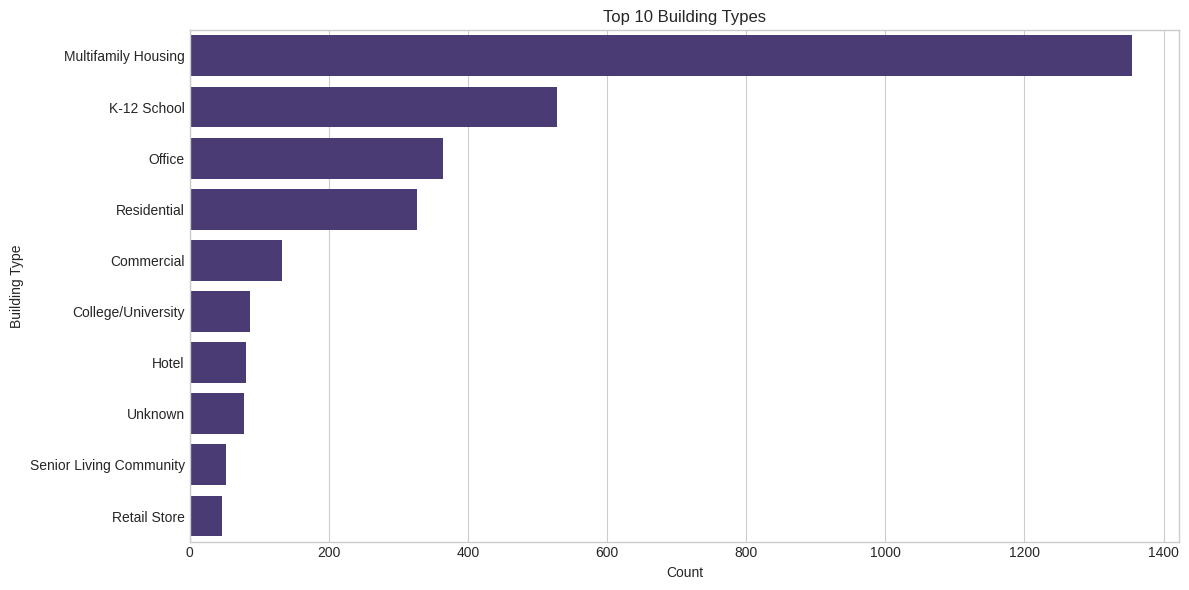

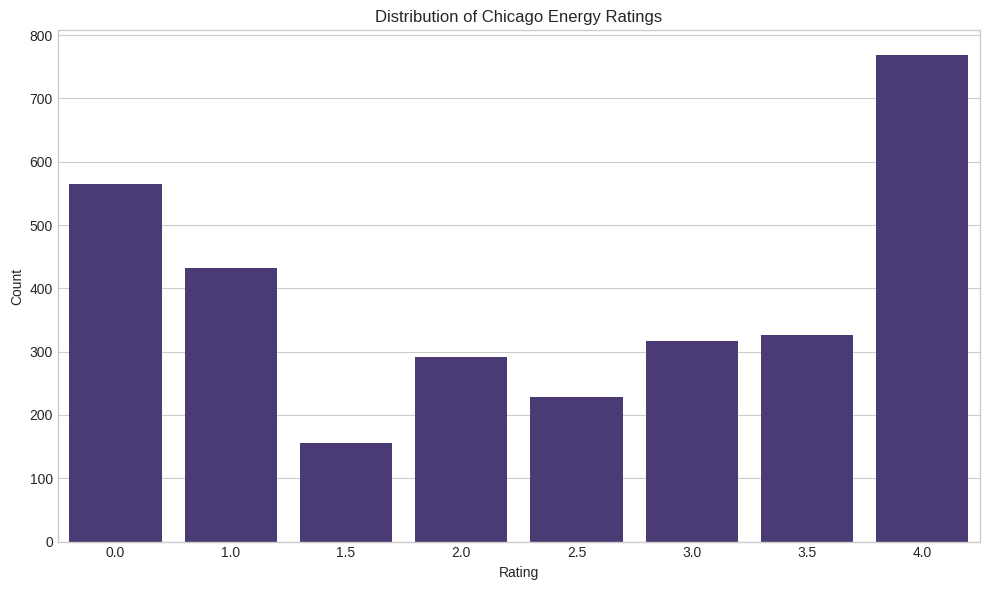

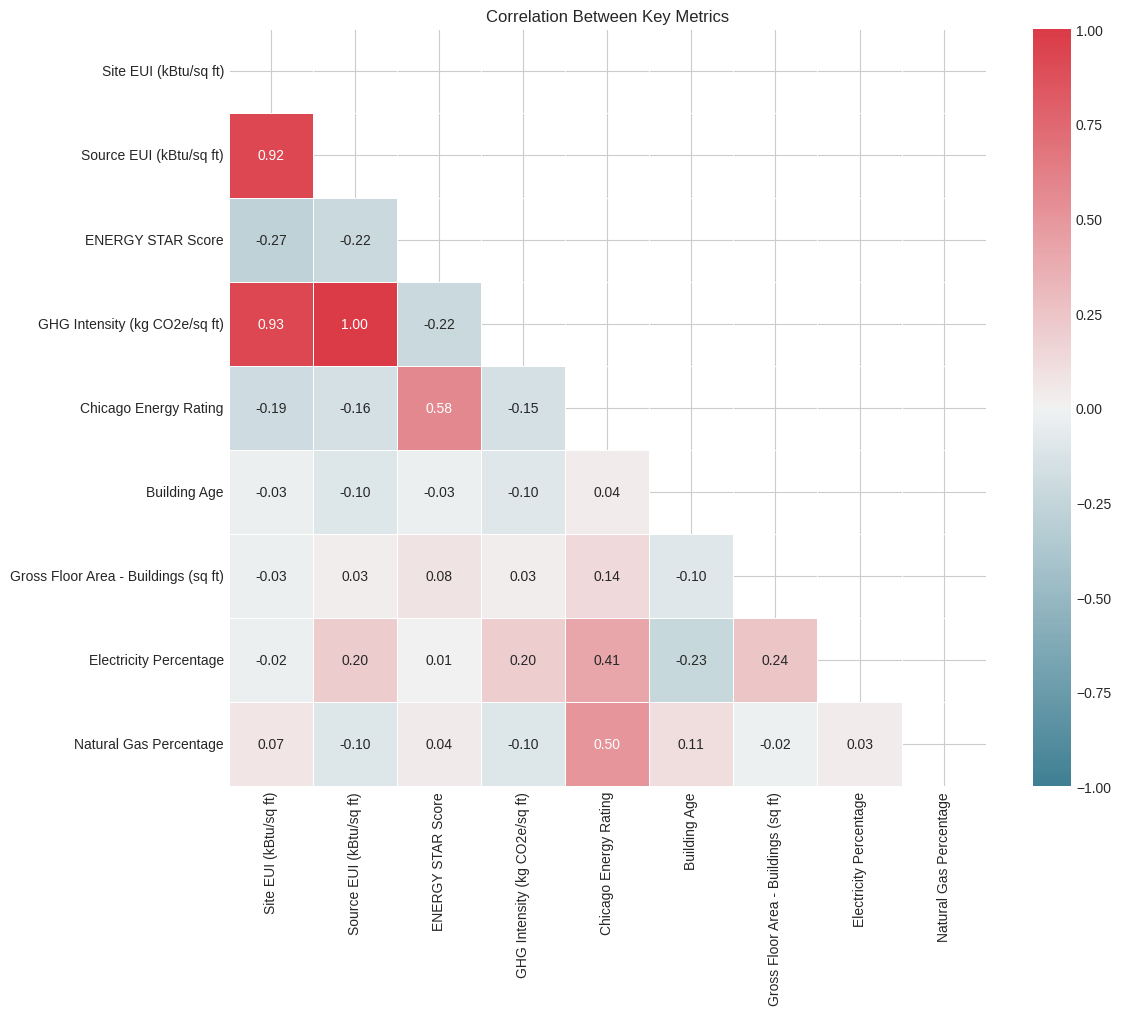

In [ ]:
# Overview of key energy metrics
energy_metrics = ['Site EUI (kBtu/sq ft)', 'Source EUI (kBtu/sq ft)', 'ENERGY STAR Score', 'GHG Intensity (kg CO2e/sq ft)']

# Calculate summary statistics
summary_stats = merged_df[energy_metrics].describe()
print("Summary Statistics for Key Energy Metrics:")
summary_stats


# Distribution of building types
building_type_counts = merged_df['Primary Property Type'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=building_type_counts.values, y=building_type_counts.index)
plt.title('Top 10 Building Types')
plt.xlabel('Count')
plt.ylabel('Building Type')
plt.tight_layout()
plt.show()


# Distribution of Chicago Energy Ratings
rating_counts = merged_df['Chicago Energy Rating'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Distribution of Chicago Energy Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(range(len(rating_counts.index)), rating_counts.index)
plt.tight_layout()
plt.show()

# Correlation between key metrics
correlation_metrics = [
    'Site EUI (kBtu/sq ft)',
    'Source EUI (kBtu/sq ft)',
    'ENERGY STAR Score',
    'GHG Intensity (kg CO2e/sq ft)',
    'Chicago Energy Rating',
    'Building Age',
    'Gross Floor Area - Buildings (sq ft)',
    'Electricity Percentage',
    'Natural Gas Percentage'
]

# Calculate correlation matrix
corr_matrix = merged_df[correlation_metrics].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, fmt='.2f')
plt.title('Correlation Between Key Metrics')
plt.tight_layout()
plt.show()


# Visualization 1: Energy Performance by Building Type

This visualization compares the average Site EUI, Source EUI, and GHG Intensity across the top building types in Chicago. Understanding which building types have the highest/lowest efficiency metrics helps city authorities target their policies and building owners benchmark against similar property types.



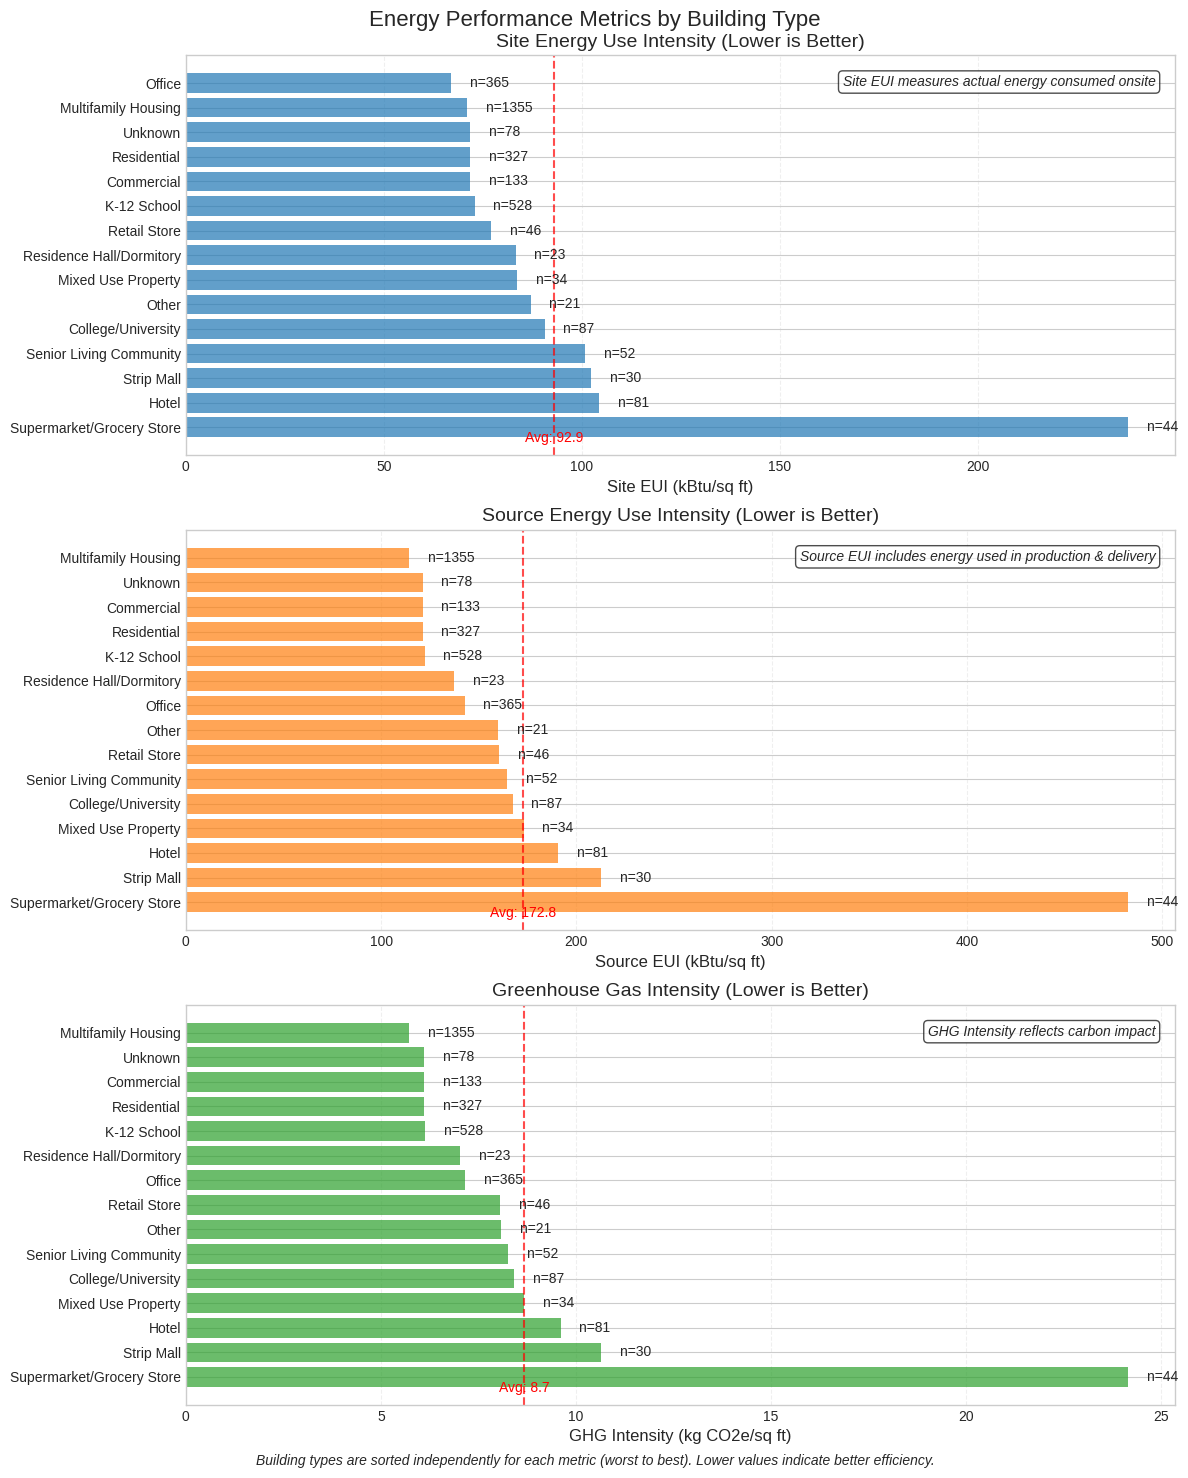

In [ ]:
merged_df = merged_df.reset_index(drop=True)

# Get the top 15 building types (matching Riya's visualization)
top_property_types = merged_df['Primary Property Type'].value_counts().head(15).index.tolist()

# Prepare data for visualization - filter to top 15 types
building_performance = merged_df[merged_df['Primary Property Type'].isin(top_property_types)].groupby('Primary Property Type').agg({
    'Site EUI (kBtu/sq ft)': 'mean',
    'Source EUI (kBtu/sq ft)': 'mean',
    'GHG Intensity (kg CO2e/sq ft)': 'mean',
    'Building ID': 'count'
}).rename(columns={'Building ID': 'Count'}).reset_index()

# Create a figure with one subplot per metric
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=False)
plt.subplots_adjust(hspace=0.3)

# Define colors for each metric
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
metrics = ['Site EUI (kBtu/sq ft)', 'Source EUI (kBtu/sq ft)', 'GHG Intensity (kg CO2e/sq ft)']
titles = ['Site Energy Use Intensity (Lower is Better)',
          'Source Energy Use Intensity (Lower is Better)',
          'Greenhouse Gas Intensity (Lower is Better)']

# Create horizontal bar plots for each metric, sorting each by its own metric
for i, (metric, title, ax, color) in enumerate(zip(metrics, titles, axes, colors)):
    # Sort data for this specific metric from highest to lowest (worst to best)
    metric_sorted_data = building_performance.sort_values(metric, ascending=False)

    # Create horizontal bar chart
    ax.barh(metric_sorted_data['Primary Property Type'],
            metric_sorted_data[metric],
            color=color,
            alpha=0.7)

    # Add count information next to each bar
    for j, (value, count) in enumerate(zip(metric_sorted_data[metric], metric_sorted_data['Count'])):
        ax.text(value + (max(metric_sorted_data[metric]) * 0.02),
                j,
                f'n={count}',
                va='center')

    # Add a vertical line for the average
    avg_value = metric_sorted_data[metric].mean()
    ax.axvline(x=avg_value, color='red', linestyle='--', alpha=0.7)
    ax.text(avg_value, -0.6, f'Avg: {avg_value:.1f}', color='red', ha='center')

    # Improve aesthetics
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(metric, fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Add a short explanation about the metric
    if i == 0:
        explanation = "Site EUI measures actual energy consumed onsite"
    elif i == 1:
        explanation = "Source EUI includes energy used in production & delivery"
    else:
        explanation = "GHG Intensity reflects carbon impact"

    ax.text(0.98, 0.95, explanation,
            transform=ax.transAxes,
            ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'),
            style='italic', fontsize=10)

# Set a main title
plt.suptitle('Energy Performance Metrics by Building Type', fontsize=16, y=0.98)

# Add a simple explanatory note
fig.text(0.5, 0.01,
         'Building types are sorted independently for each metric (worst to best). Lower values indicate better efficiency.',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.95, bottom=0.05)
plt.show()



#  Implications for Building Owners
This visualization helps building owners understand how their property type typically performs and what energy metrics they should expect. For example, if you own an office building and your Site EUI is significantly higher than the average shown here, it suggests substantial room for improvement. The fact that different building types show distinct energy profiles confirms our hypothesis that building characteristics significantly predict energy performance.
# Implications for City Authorities
For city planners, this visualization identifies which building categories should be prioritized in energy efficiency programs. Building types with both high average energy intensity and large building counts (like multifamily housing) represent the greatest opportunity for citywide emissions reduction. Targeted policies and incentives for these specific building types would yield the highest impact.

# Visualization 2: Energy Source Distribution by Building Type

This visualization shows how different building types utilize various energy sources (electricity, natural gas, etc.). The mix of energy sources can significantly impact a building's overall efficiency and emissions. This visualization tests our hypothesis that different energy sources have varying optimization opportunities.


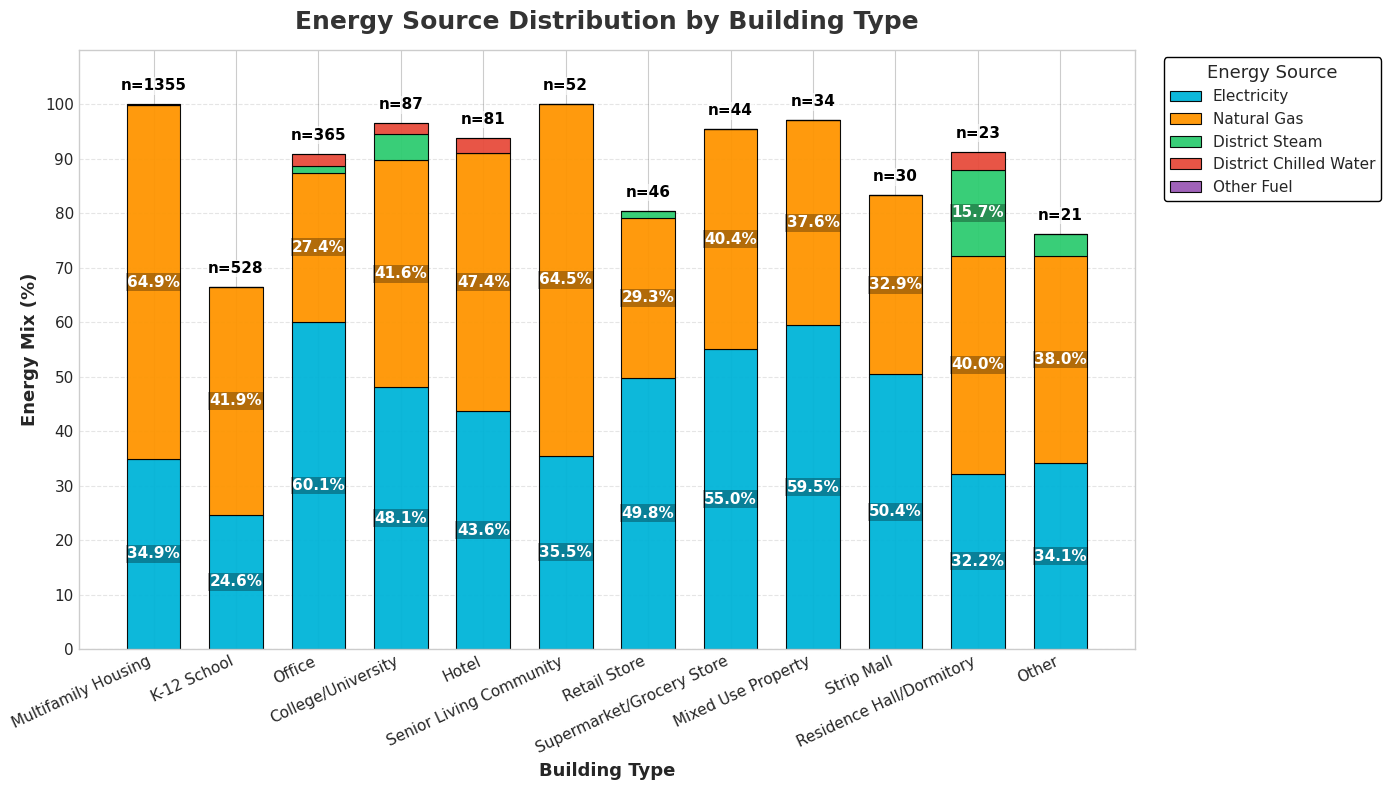

In [ ]:

# Prepare data for energy source distribution
top_property_types = merged_df['Primary Property Type'].value_counts().head(15).index.tolist()
energy_source_df = merged_df[merged_df['Primary Property Type'].isin(top_property_types)].copy()

# Calculate average percentages for each building type (unchanged)
energy_source_summary = energy_source_df.groupby('Primary Property Type').agg({
    'Electricity Percentage': 'mean',
    'Natural Gas Percentage': 'mean',
    'District Steam Percentage': 'mean',
    'District Chilled Water Percentage': 'mean',
    'All Other Fuel Percentage': 'mean',
    'Building ID': 'count'
}).rename(columns={'Building ID': 'Count'}).reset_index()

# Sort by count (unchanged)
energy_source_summary = energy_source_summary.sort_values('Count', ascending=False)

# Remove categories with all-zero energy percentages
energy_source_summary = energy_source_summary[
    energy_source_summary[['Electricity Percentage', 'Natural Gas Percentage',
                           'District Steam Percentage', 'District Chilled Water Percentage',
                           'All Other Fuel Percentage']].sum(axis=1) > 0
]

# Set Seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Define energy sources with vibrant colors
energy_sources = [
    ('Electricity Percentage', '#00b4d8', 'Electricity'),
    ('Natural Gas Percentage', '#ff9500', 'Natural Gas'),
    ('District Steam Percentage', '#2ecc71', 'District Steam'),
    ('District Chilled Water Percentage', '#e74c3c', 'District Chilled Water'),
    ('All Other Fuel Percentage', '#9b59b6', 'Other Fuel')
]

# Initialize bottom values
bottom_values = np.zeros(len(energy_source_summary))
x = np.arange(len(energy_source_summary))

# Plot stacked bars
for source, color, label in energy_sources:
    values = energy_source_summary[source].fillna(0)
    plt.bar(
        x,
        values,
        bottom=bottom_values,
        label=label,
        color=color,
        width=0.65,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.95
    )
    # Add percentage labels if > 5%
    for i, (val, bottom) in enumerate(zip(values, bottom_values)):
        if val > 5:
            plt.text(
                x[i], bottom + val / 2, f'{val:.1f}%',
                ha='center', va='center', color='white', fontsize=11, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.3, edgecolor='none', pad=1)
            )
    bottom_values += values

# Customize axes and labels
plt.xlabel('Building Type', fontsize=13, weight='bold')
plt.ylabel('Energy Mix (%)', fontsize=13, weight='bold')
plt.title('Energy Source Distribution by Building Type', fontsize=18, weight='bold', pad=15,
          color='#333333')
plt.xticks(x, energy_source_summary['Primary Property Type'], rotation=25, ha='right', fontsize=11)
plt.yticks(np.arange(0, 101, 10), fontsize=11)

# Add count annotations
for i, count in enumerate(energy_source_summary['Count']):
    total_height = sum(energy_source_summary[source].iloc[i] for source, _, _ in energy_sources)
    plt.text(
        x[i], total_height + 2, f'n={count}',
        ha='center', va='bottom', fontsize=11, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
    )

# Enhance legend
plt.legend(
    title='Energy Source', title_fontsize=13, fontsize=11,
    bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='black',
    facecolor='white', framealpha=1
)

# Add grid and adjust layout
plt.grid(axis='y', linestyle='--', alpha=0.2, color='gray')
plt.ylim(0, 110)
plt.tight_layout()

plt.show()


#Implications for Building Owners
The energy source distribution reveals important patterns that building owners can use to optimize their energy strategy. Buildings with higher electricity usage often have different efficiency challenges than those relying primarily on natural gas. Owners can compare their building's energy mix to similar properties and identify opportunities to shift toward a more optimal distribution. For instance, if your office building uses significantly more natural gas than the average, exploring electrification options might be beneficial.
#  Implications for City Authorities
This visualization helps authorities understand the energy infrastructure needs across different building sectors. It can inform policies related to grid modernization, electrification incentives, or natural gas efficiency programs based on the predominant energy sources used by different building types. For example, targeted electrification programs for building types that currently rely heavily on natural gas could yield significant emissions reductions.

# Visualization 3: Performance by Building Age

This visualization examines how building age relates to energy performance. It helps us understand if older buildings consistently underperform newer ones, and at what age buildings tend to see efficiency declines. This addresses our hypothesis that building characteristics (specifically age) significantly predict energy performance.


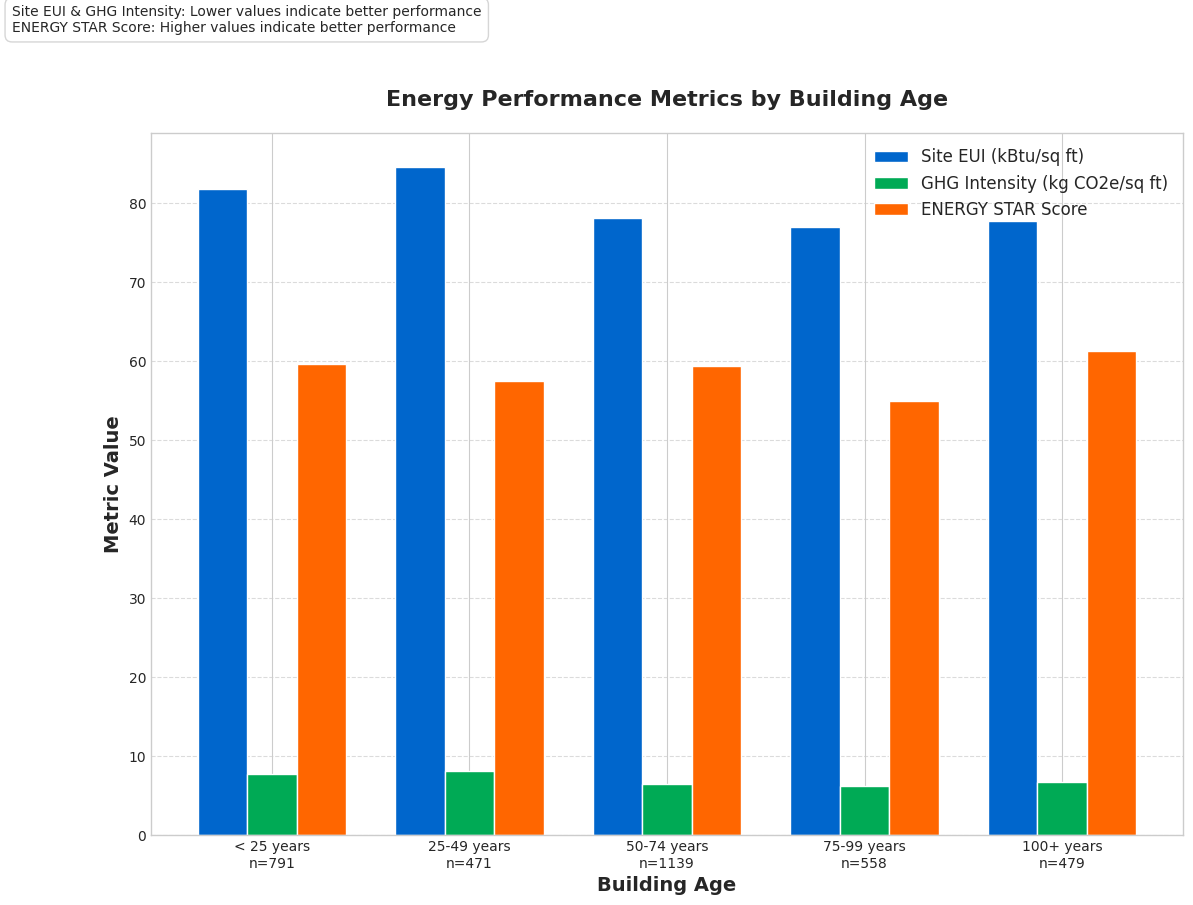

In [ ]:
# Reset index to avoid ambiguity
merged_df = merged_df.reset_index(drop=True)

# Group by age category and calculate mean metrics
age_performance = merged_df.groupby('Age Category').agg({
    'Site EUI (kBtu/sq ft)': 'mean',
    'ENERGY STAR Score': 'mean',
    'GHG Intensity (kg CO2e/sq ft)': 'mean',
    'Building ID': 'count'
}).rename(columns={'Building ID': 'Count'}).reset_index()

# Order categories properly for plotting
correct_order = ['< 25 years', '25-49 years', '50-74 years', '75-99 years', '100+ years']
age_performance['Age Category'] = pd.Categorical(
    age_performance['Age Category'],
    categories=correct_order,
    ordered=True
)
age_performance = age_performance.sort_values('Age Category')

# Set color scheme
site_eui_color = '#0066cc'  # Blue
ghg_color = '#00aa55'       # Green
energy_star_color = '#ff6600'  # Orange

# Create a figure with more space at the bottom for legend and annotations
plt.figure(figsize=(12, 9))  # Increased height to make room for annotations

# Create positions for the bars
x = np.arange(len(age_performance['Age Category']))
width = 0.25  # Width of the bars

# Create bars for each metric
plt.bar(x - width, age_performance['Site EUI (kBtu/sq ft)'], width, label='Site EUI (kBtu/sq ft)', color=site_eui_color)
plt.bar(x, age_performance['GHG Intensity (kg CO2e/sq ft)'], width, label='GHG Intensity (kg CO2e/sq ft)', color=ghg_color)
plt.bar(x + width, age_performance['ENERGY STAR Score'], width, label='ENERGY STAR Score', color=energy_star_color)

# Add labels and title
plt.xlabel('Building Age', fontsize=14, fontweight='bold')
plt.ylabel('Metric Value', fontsize=14, fontweight='bold')
plt.title('Energy Performance Metrics by Building Age', fontsize=16, fontweight='bold', pad=20)

# Add custom x-tick labels with counts
plt.xticks(x, [f"{age}\nn={count}" for age, count in zip(age_performance['Age Category'], age_performance['Count'])])

# Add legend in a better position - move to upper right to avoid overlap
plt.legend(loc='upper right', fontsize=12)

# Add annotation explaining metrics - moved to the top left instead of bottom
# Also using a text box to make it more readable
plt.annotate(
    "Site EUI & GHG Intensity: Lower values indicate better performance\nENERGY STAR Score: Higher values indicate better performance",
    xy=(0.01, 0.97),
    xycoords='figure fraction',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cccccc', boxstyle='round,pad=0.5')
)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust bottom margin to leave more space
plt.subplots_adjust(bottom=0.15)

plt.tight_layout()
plt.show()

#Implications for Building Owners
This visualization shows how a building's age typically affects its energy performance. Owners of older buildings can use this information to contextualize their building's performance and set realistic improvement targets. Interestingly, the data shows that very old buildings (100+ years) sometimes perform better than those from certain mid-century periods, possibly due to retrofits or architectural features. This suggests that even owners of very old buildings can achieve significant efficiency improvements with the right approaches.

# Implications for City Authorities
For policymakers, this visualization helps identify which building age groups should be targeted for retrofitting programs. Buildings from eras with consistently poor performance represent prime opportunities for efficiency improvements. This could inform age-specific building codes, retrofit requirements, or incentive programs tailored to the unique challenges of buildings from different time periods.


# Visualization 4: Geographic Energy Efficiency Map

This visualization creates a geographical map of Chicago showing energy efficiency patterns across different neighborhoods. It helps test our hypothesis that energy performance varies systematically by neighborhood and location. Using an interactive map allows stakeholders to explore spatial patterns that might not be apparent in tabular data.


Map created and saved as 'chicago_energy_map.html'
The size of each circle represents the number of buildings in that area.


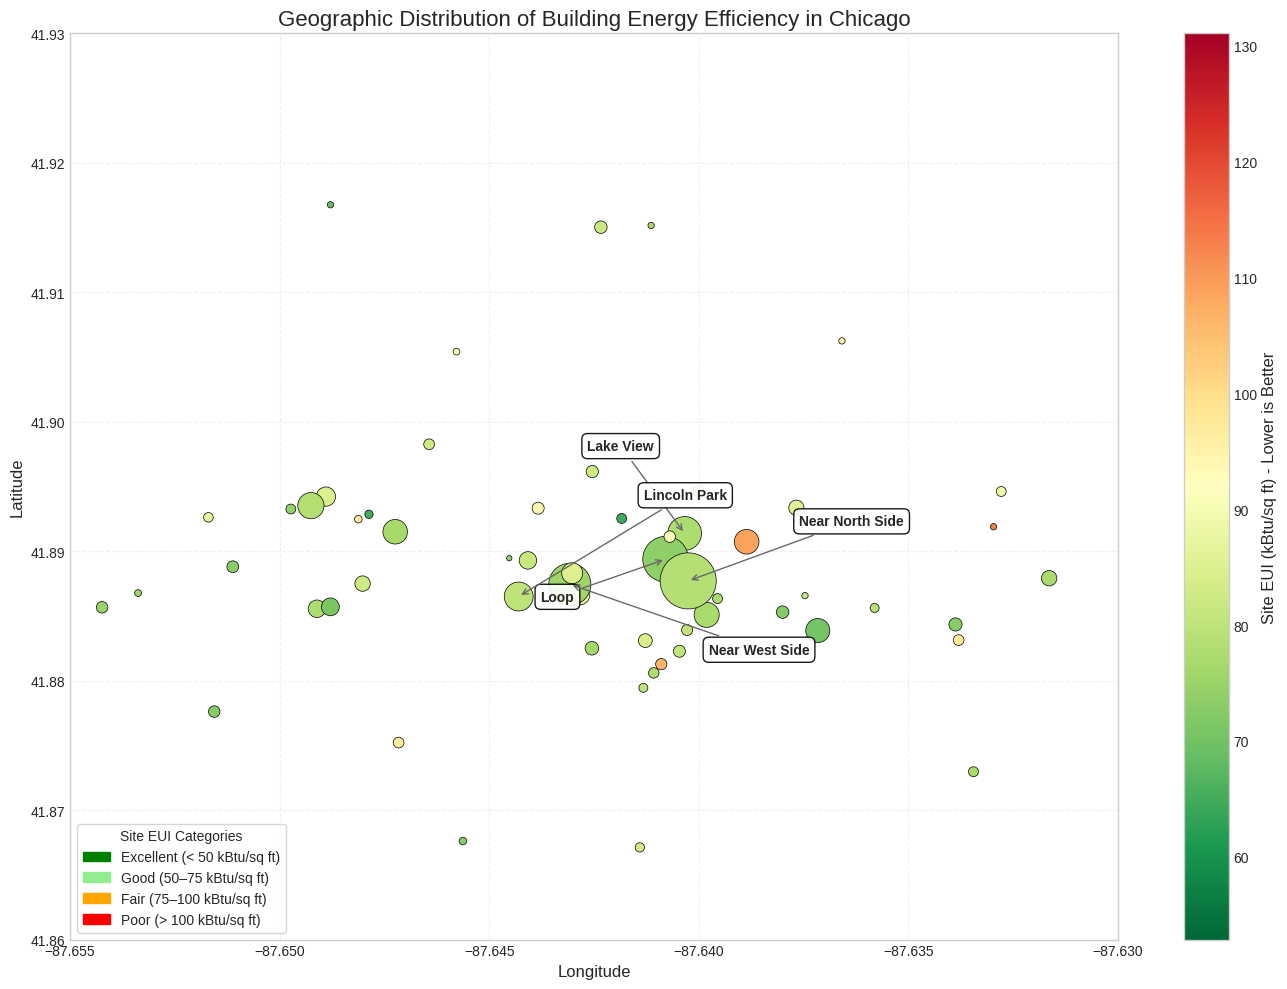

In [ ]:
# Prepare data for mapping
# Calculate average metrics by community area
community_metrics = merged_df.groupby('Community Area').agg({
    'Site EUI (kBtu/sq ft)': 'mean',
    'GHG Intensity (kg CO2e/sq ft)': 'mean',
    'ENERGY STAR Score': 'mean',
    'Latitude': 'median',
    'Longitude': 'median',
    'Building ID': 'count'
}).rename(columns={'Building ID': 'Count', 'Latitude_y': 'Latitude',
    'Longitude_y': 'Longitude'}).reset_index()

# Remove rows with missing coordinates
community_metrics = community_metrics.dropna(subset=['Latitude', 'Longitude'])

# Create a map centered on Chicago
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Define a function to determine circle color based on Site EUI
def get_color(eui):
    if pd.isna(eui):
        return 'grey'
    elif eui < 50:
        return 'green'
    elif eui < 75:
        return 'lightgreen'
    elif eui < 100:
        return 'orange'
    else:
        return 'red'

# Create a circle marker for each community area
for idx, row in community_metrics.iterrows():
    if pd.isna(row['Site EUI (kBtu/sq ft)']) or pd.isna(row['Latitude']) or pd.isna(row['Longitude']):
        continue

    # Format popup content
    popup_content = f"""
    <b>Community Area:</b> {row['Community Area']}<br>
    <b>Avg Site EUI:</b> {row['Site EUI (kBtu/sq ft)']:.1f} kBtu/sq ft<br>
    <b>Avg GHG Intensity:</b> {row['GHG Intensity (kg CO2e/sq ft)']:.1f} kg CO2e/sq ft<br>
    <b>Avg ENERGY STAR Score:</b> {row['ENERGY STAR Score']:.1f}<br>
    <b>Number of Buildings:</b> {row['Count']}
    """

    # Determine circle size based on building count (with minimum size for visibility)
    radius = max(5, min(15, row['Count'] / 10))

    # Add circle marker
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=radius,
        color=get_color(row['Site EUI (kBtu/sq ft)']),
        fill=True,
        fill_color=get_color(row['Site EUI (kBtu/sq ft)']),
        fill_opacity=0.7,
        popup=folium.Popup(popup_content, max_width=300)
    ).add_to(chicago_map)

# Add a legend
legend_html = '''
<div style="position: fixed;
            bottom: 50px; right: 50px; width: 180px; height: 120px;
            border:2px solid grey; z-index:9999; font-size:14px;
            background-color:white; padding: 10px;
            border-radius: 5px;">
    <div style="margin-bottom: 5px;"><b>Site EUI (kBtu/sq ft)</b></div>
    <div style="display: flex; align-items: center; margin-bottom: 5px;">
        <div style="width: 20px; height: 20px; background-color: green; margin-right: 10px;"></div>
        < 50 (Excellent)
    </div>
    <div style="display: flex; align-items: center; margin-bottom: 5px;">
        <div style="width: 20px; height: 20px; background-color: lightgreen; margin-right: 10px;"></div>
        50 - 75 (Good)
    </div>
    <div style="display: flex; align-items: center; margin-bottom: 5px;">
        <div style="width: 20px; height: 20px; background-color: orange; margin-right: 10px;"></div>
        75 - 100 (Fair)
    </div>
    <div style="display: flex; align-items: center;">
        <div style="width: 20px; height: 20px; background-color: red; margin-right: 10px;"></div>
        > 100 (Poor)
    </div>
</div>
'''
chicago_map.get_root().html.add_child(folium.Element(legend_html))

# Save the map to an HTML file
chicago_map.save('chicago_energy_map.html')

# Display the map in the notebook (placeholder since we can't directly show the interactive map)
print("Map created and saved as 'chicago_energy_map.html'")

print("The size of each circle represents the number of buildings in that area.")

# Create a static alternative for the report using matplotlib
plt.figure(figsize=(14, 10))

# Create a scatter plot with better readability
scatter = plt.scatter(
    community_metrics['Longitude'],
    community_metrics['Latitude'],
    c=community_metrics['Site EUI (kBtu/sq ft)'],
    cmap='RdYlGn_r',
    s=community_metrics['Count'] * 3,  # Slightly larger circles
    alpha=1,  # Add transparency for overlap
    edgecolors='black',
    linewidths=0.5
)

# Zoom in to reduce empty space and enhance focus
plt.xlim(-87.655, -87.630)
plt.ylim(41.86, 41.93)

offsets = [(80, 40), (-90, -30), (100, -50), (-70, 60), (90, 70)]

for i, (idx, row) in enumerate(community_metrics.sort_values('Count', ascending=False).head(5).iterrows()):
    dx, dy = offsets[i % len(offsets)]
    plt.annotate(
        row['Community Area'],
        xy=(row['Longitude'], row['Latitude']),           # Anchor point
        xytext=(dx, dy),                                  # Distant offset
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='dimgray', lw=1),
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='black', alpha=0.9)
    )


# Add a colorbar and labels
cbar = plt.colorbar(scatter)
cbar.set_label('Site EUI (kBtu/sq ft) - Lower is Better', fontsize=12)

plt.title('Geographic Distribution of Building Energy Efficiency in Chicago', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Custom legend (same as folium)
legend_patches = [
    mpatches.Patch(color='green', label='Excellent (< 50 kBtu/sq ft)'),
    mpatches.Patch(color='lightgreen', label='Good (50–75 kBtu/sq ft)'),
    mpatches.Patch(color='orange', label='Fair (75–100 kBtu/sq ft)'),
    mpatches.Patch(color='red', label='Poor (> 100 kBtu/sq ft)')
]
plt.legend(handles=legend_patches, title='Site EUI Categories', loc='lower left', frameon=True)

plt.tight_layout()
plt.show()

#Implications for Building Owners
This geographic visualization helps building owners understand how their location might influence energy performance. Owners can see if their building is in a high-performing or low-performing area, which might indicate neighborhood-specific factors affecting efficiency (such as building age clusters, local infrastructure, or microclimates). This information can help owners contextualize their building's performance and identify location-specific strategies for improvement.

# Implications for City Authorities
For city planners, this map reveals neighborhood-level patterns that can guide targeted interventions. Areas with consistently poor energy performance (shown in red) could benefit from focused outreach programs, community-based efficiency initiatives, or neighborhood-specific incentives. The map also helps identify if certain areas have been left behind in energy improvements, enabling more equitable distribution of resources across the city. Additionally, this spatial analysis can inform infrastructure planning, such as district heating/cooling systems for neighborhoods with clusters of inefficient buildings.


# Visualization 5: Performance Outlier Analysis

This visualization identifies buildings that significantly outperform or underperform their peers of the same type and size. By highlighting these outliers, we can better understand what makes certain buildings exceptional (both positively and negatively). This directly addresses the observation that similar buildings can show energy consumption variations of up to 3-5 times.


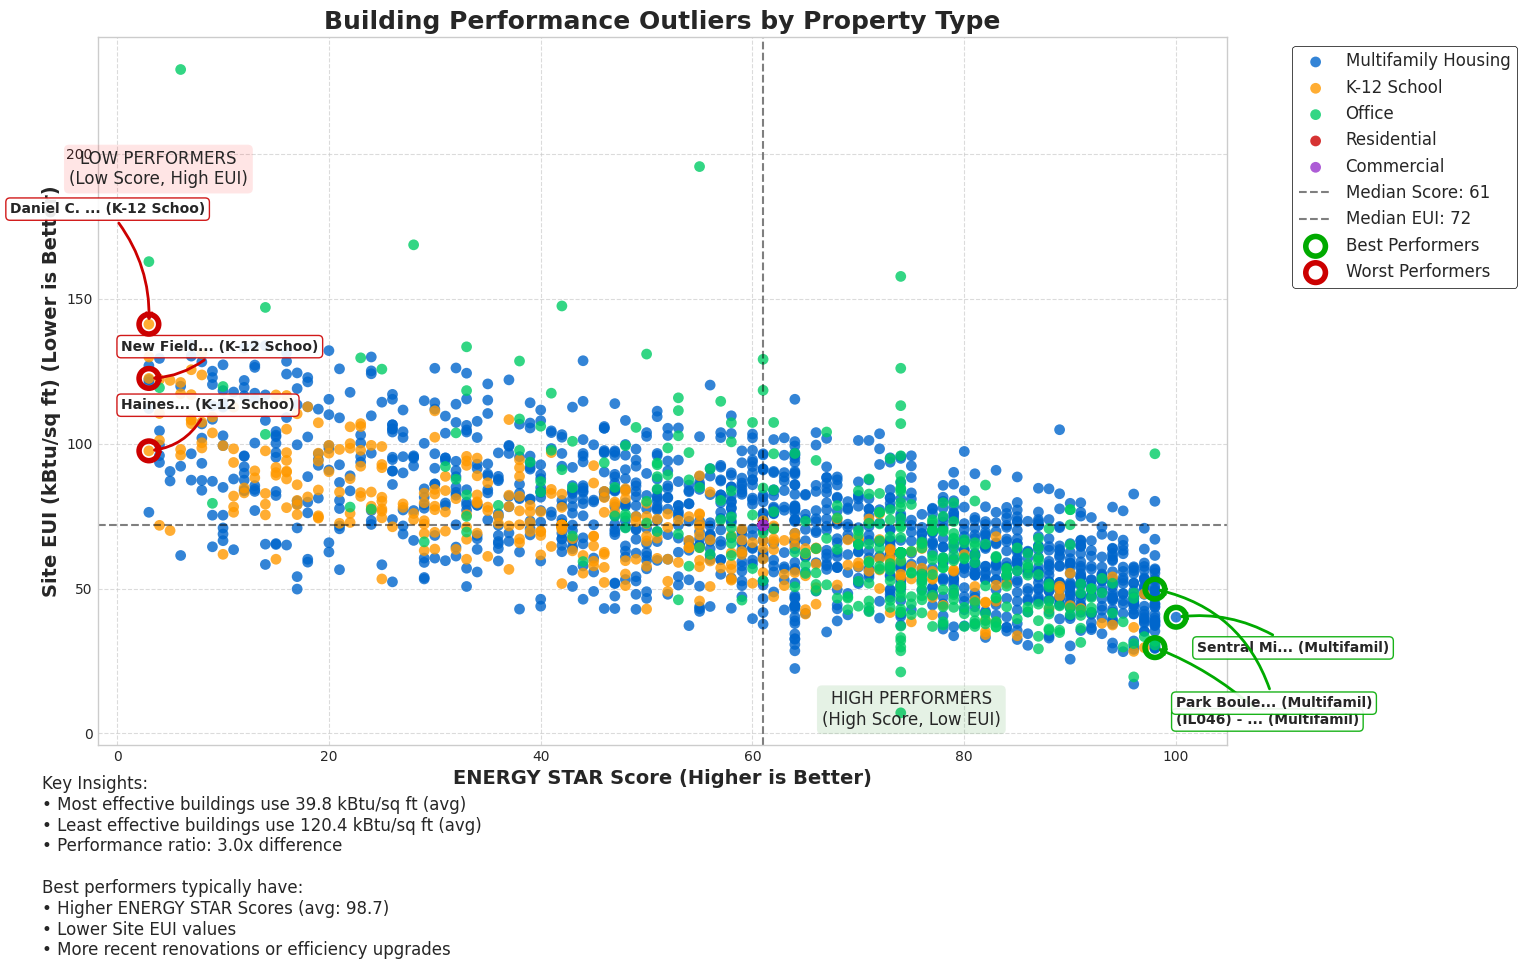

In [ ]:
# Reset index to avoid ambiguity
merged_df = merged_df.reset_index(drop=True)

# Create a scatter plot of ENERGY STAR Score vs Site EUI, colored by performance category
# First, filter to buildings with both metrics
performance_df = merged_df.dropna(subset=['ENERGY STAR Score', 'Site EUI (kBtu/sq ft)', 'Performance Category'])

# Create a bigger figure to allow more space for insights box
plt.figure(figsize=(16, 10))

# Get the top 5 property types by count
top_property_types = performance_df['Primary Property Type'].value_counts().head(5).index.tolist()

# Filter to these property types
filtered_df = performance_df[performance_df['Primary Property Type'].isin(top_property_types)]

# Create a new highly contrasting color palette for maximum distinction
property_colors = {
    top_property_types[0]: '#0066cc',  # Deep blue
    top_property_types[1]: '#ff9900',  # Orange
    top_property_types[2]: '#00cc66',  # Bright green
    top_property_types[3]: '#cc0000',  # Bright red
    top_property_types[4]: '#9933cc'   # Deep purple
}

# Create a scatter plot with property types
for prop_type, color in property_colors.items():
    subset = filtered_df[filtered_df['Primary Property Type'] == prop_type]
    plt.scatter(
        subset['ENERGY STAR Score'],
        subset['Site EUI (kBtu/sq ft)'],
        c=color,
        label=prop_type,
        alpha=0.8,  # Increased from 0.6 for better visibility
        s=60,
        edgecolors='none'
    )

# Calculate overall medians for all filtered properties
median_score = filtered_df['ENERGY STAR Score'].median()
median_eui = filtered_df['Site EUI (kBtu/sq ft)'].median()

# Add quadrant lines
plt.axvline(x=median_score, color='black', linestyle='--', alpha=0.5, label=f'Median Score: {median_score:.0f}')
plt.axhline(y=median_eui, color='black', linestyle='--', alpha=0.5, label=f'Median EUI: {median_eui:.0f}')

# Find extreme outliers - top 3 best and worst performers across filtered property types
# Best: High ENERGY STAR, Low EUI
best_performers = filtered_df.nlargest(3, 'ENERGY STAR Score')
# Worst: Low ENERGY STAR, High EUI
worst_performers = filtered_df.nsmallest(3, 'ENERGY STAR Score')

# Highlight these extreme outliers with thicker borders for better visibility
plt.scatter(
    best_performers['ENERGY STAR Score'],
    best_performers['Site EUI (kBtu/sq ft)'],
    s=200,
    facecolors='none',
    edgecolors='#00aa00',  # Darker green for better contrast
    linewidths=4,         # Thicker line
    label='Best Performers',
    zorder=10
)

plt.scatter(
    worst_performers['ENERGY STAR Score'],
    worst_performers['Site EUI (kBtu/sq ft)'],
    s=200,
    facecolors='none',
    edgecolors='#cc0000',  # Bright red
    linewidths=4,          # Thicker line
    label='Worst Performers',
    zorder=10
)

# Add annotations with better positioning for best performers
for i, (idx, row) in enumerate(best_performers.iterrows()):
    prop_name = str(row.get('Property Name', f'Building {idx}'))
    prop_type = str(row.get('Primary Property Type', 'Unknown'))

    # Calculate different offset positions for each point to avoid overlap
    if i == 0:
        x_offset = 15
        y_offset = -25
        connection_style = 'arc3,rad=0.2'
    elif i == 1:
        x_offset = 15
        y_offset = -55  # More vertical separation
        connection_style = 'arc3,rad=0.1'
    else:
        x_offset = 15
        y_offset = -85  # Even more vertical separation
        connection_style = 'arc3,rad=0.3'

    plt.annotate(
        f"{prop_name[:10]}... ({prop_type[:10]})",
        xy=(row['ENERGY STAR Score'], row['Site EUI (kBtu/sq ft)']),
        xytext=(x_offset, y_offset),  # Different offset for each annotation
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            connectionstyle=connection_style,
            color='#00aa00',
            lw=2
        ),
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='white',
            ec='#00aa00',
            alpha=0.9
        )
    )

# Add annotations with better positioning for worst performers
for i, (idx, row) in enumerate(worst_performers.iterrows()):
    prop_name = str(row.get('Property Name', f'Building {idx}'))
    prop_type = str(row.get('Primary Property Type', 'Unknown'))

    # Calculate different offset positions for each point
    if i == 0:
        x_offset = -20  # Position more to the left
        y_offset = 20
        connection_style = 'arc3,rad=-0.2'  # Curve the arrow differently
    elif i == 1:
        x_offset = -20  # Even more to the left
        y_offset = 30
        connection_style = 'arc3,rad=-0.3'
    else:
        x_offset = -100
        y_offset = 80  # Significant vertical separation
        connection_style = 'arc3,rad=-0.2'

    plt.annotate(
        f"{prop_name[:10]}... ({prop_type[:10]})",
        xy=(row['ENERGY STAR Score'], row['Site EUI (kBtu/sq ft)']),
        xytext=(x_offset, y_offset),  # Different offset for each annotation
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            connectionstyle=connection_style,  # Different curve for each arrow
            color='#cc0000',
            lw=2
        ),
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='white',
            ec='#cc0000',
            alpha=0.9
        )
    )

# Add quadrant labels
x_max = filtered_df['ENERGY STAR Score'].max()
x_min = filtered_df['ENERGY STAR Score'].min()
y_max = filtered_df['Site EUI (kBtu/sq ft)'].max()
y_min = filtered_df['Site EUI (kBtu/sq ft)'].min()

# Position the HIGH PERFORMERS label with more space to avoid overlap with annotations
plt.text(x_max * 0.75, y_min * 1.15,
        'HIGH PERFORMERS\n(High Score, Low EUI)',
        fontsize=12, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='green', alpha=0.1))

# Position the LOW PERFORMERS label to avoid overlap with annotations
plt.text(x_min * 1.3, y_max * 0.85,
        'LOW PERFORMERS\n(Low Score, High EUI)',
        fontsize=12, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.1))

# Add title and labels
plt.title('Building Performance Outliers by Property Type', fontsize=18, fontweight='bold')
plt.xlabel('ENERGY STAR Score (Higher is Better)', fontsize=14, fontweight='bold')
plt.ylabel('Site EUI (kBtu/sq ft) (Lower is Better)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

# Improve legend with larger marker size and a border
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, frameon=True, framealpha=1)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)

# Create insights text
insights_text = f'''Key Insights:
• Most effective buildings use {best_performers["Site EUI (kBtu/sq ft)"].mean():.1f} kBtu/sq ft (avg)
• Least effective buildings use {worst_performers["Site EUI (kBtu/sq ft)"].mean():.1f} kBtu/sq ft (avg)
• Performance ratio: {worst_performers["Site EUI (kBtu/sq ft)"].mean() / best_performers["Site EUI (kBtu/sq ft)"].mean():.1f}x difference

Best performers typically have:
• Higher ENERGY STAR Scores (avg: {best_performers["ENERGY STAR Score"].mean():.1f})
• Lower Site EUI values
• More recent renovations or efficiency upgrades'''

# BETTER POSITIONING: Create a separate axes for the insights box
# This prevents overlapping with the main visualization
ins_ax = plt.axes([0.05, 0.03, 0.3, 0.2], frameon=True)  # [left, bottom, width, height]
ins_ax.text(0.05, 0.95, insights_text, fontsize=12,
           verticalalignment='top', horizontalalignment='left',
           transform=ins_ax.transAxes)
ins_ax.axis('off')  # Hide the axes

# Add a thin border around the insights box for better definition
ins_ax.patch.set_edgecolor('black')
ins_ax.patch.set_linewidth(0.5)
ins_ax.patch.set_facecolor('white')
ins_ax.patch.set_alpha(0.9)

# Make sure the main plot doesn't overlap with the insights box
plt.tight_layout()
plt.subplots_adjust(left=0.1, bottom=0.25)
plt.show()

# Implications for Building Owners
This outlier analysis provides building owners with a clear picture of how their property performs relative to peers with similar characteristics. It helps owners set realistic targets based on what has actually been achieved by comparable buildings. For owners of underperforming buildings (shown in orange and red), it demonstrates that significant improvements are possible, since similar buildings are performing much better. For those with high-performing buildings, it validates their efficiency efforts and may identify opportunities for recognition or certification.

# Implications for City Authorities
City planners can use this outlier analysis to identify success stories and problem cases across the building stock. The exceptional performers (green) can serve as case studies for effective efficiency strategies, while the worst performers (red) might need targeted intervention or enforcement. The wide performance spread among similar buildings indicates that there's significant untapped potential for energy savings without requiring major technological breakthroughs – simply bringing underperforming buildings up to the standards of their peers would yield substantial energy and emissions reductions.


# Machine Learning Model 1: Energy Star Score Prediction

Our first machine learning model aims to predict a building's ENERGY STAR Score based on its characteristics and energy usage patterns. This model can help building owners understand which factors most influence their energy performance rating and what improvements might increase their score.


Training data shape: (2579, 6)
Testing data shape: (645, 6)
Baseline Model (Mean Prediction):
Mean Squared Error: 463.99
R² Score: -0.00
Root Mean Squared Error: 21.54

Random Forest Model:
Mean Squared Error: 134.88
R² Score: 0.71
Root Mean Squared Error: 11.61

Improvement over baseline:
MSE reduction: 70.93%
RMSE reduction: 46.08%


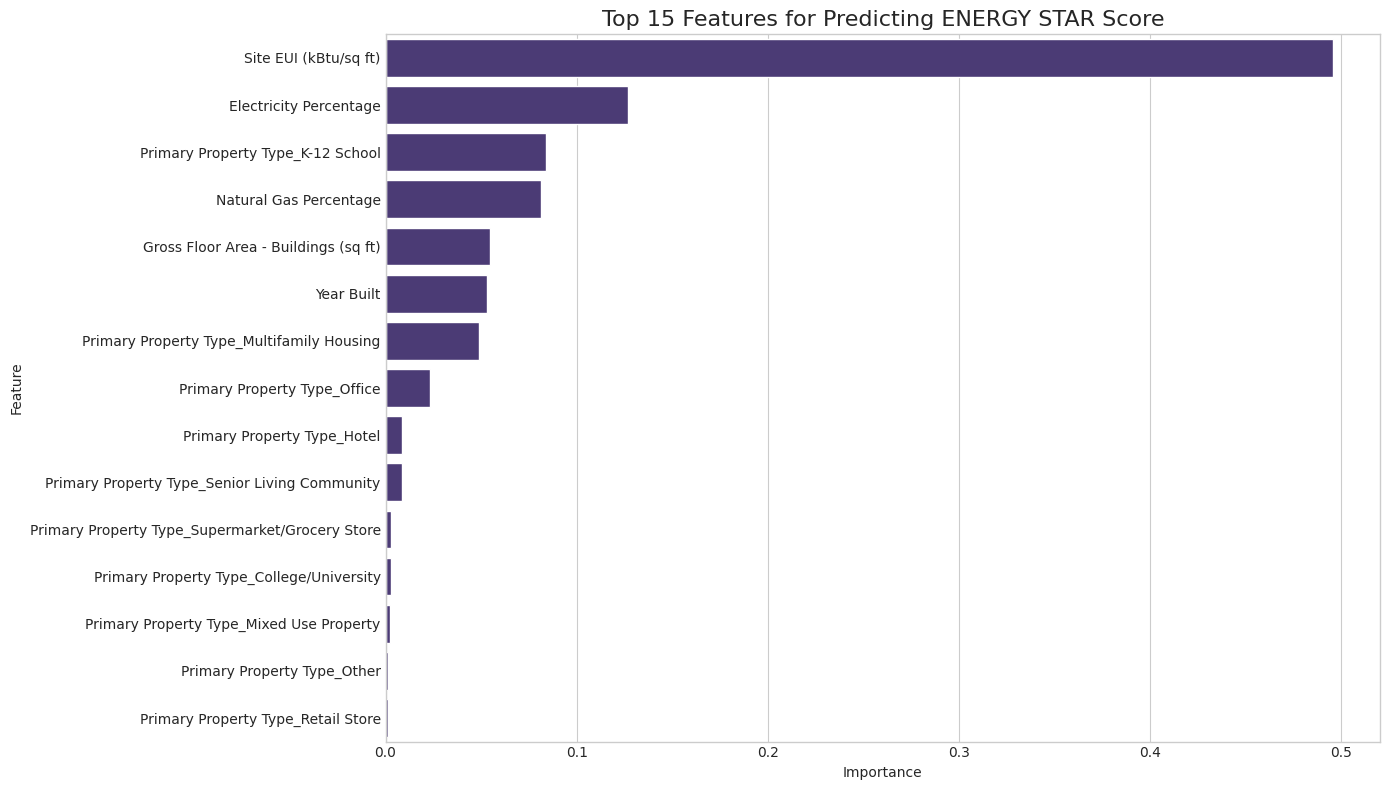

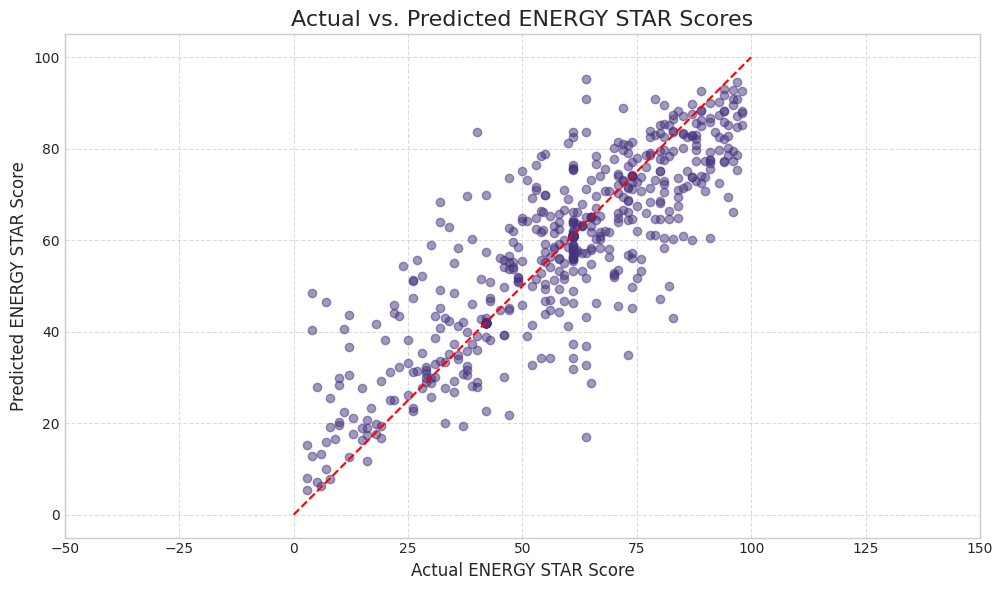

In [ ]:
# Reset index to avoid ambiguity
merged_df = merged_df.reset_index(drop=True)

# Prepare data for modeling
model_data = merged_df.dropna(subset=['ENERGY STAR Score']).copy()

# Select features
features = [
    'Primary Property Type',
    'Gross Floor Area - Buildings (sq ft)',
    'Year Built',
    'Electricity Percentage',
    'Natural Gas Percentage',
    'Site EUI (kBtu/sq ft)'
]

# Remove rows with missing values in features
model_data = model_data.dropna(subset=features)

# Ensure we have common property types (at least 20 buildings)
property_counts = model_data['Primary Property Type'].value_counts()
common_types = property_counts[property_counts >= 20].index
model_data = model_data[model_data['Primary Property Type'].isin(common_types)]

# Get features (X) and target (y)
X = model_data[features].copy()
y = model_data['ENERGY STAR Score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


# Create preprocessing steps for categorical and numerical features
categorical_features = ['Primary Property Type']
numeric_features = [
    'Gross Floor Area - Buildings (sq ft)',
    'Year Built',
    'Electricity Percentage',
    'Natural Gas Percentage',
    'Site EUI (kBtu/sq ft)'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create baseline model (mean prediction)
baseline_pred = np.ones(len(y_test)) * y_train.mean()
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Model (Mean Prediction):")
print(f"Mean Squared Error: {baseline_mse:.2f}")
print(f"R² Score: {baseline_r2:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(baseline_mse):.2f}")


# Create and train a Random Forest model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
rf_rmse = np.sqrt(rf_mse)

print("\nRandom Forest Model:")
print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R² Score: {rf_r2:.2f}")
print(f"Root Mean Squared Error: {rf_rmse:.2f}")

# Compare with baseline
print(f"\nImprovement over baseline:")
print(f"MSE reduction: {(baseline_mse - rf_mse) / baseline_mse * 100:.2f}%")
print(f"RMSE reduction: {(np.sqrt(baseline_mse) - rf_rmse) / np.sqrt(baseline_mse) * 100:.2f}%")


# Feature importance
def get_feature_importance(model, preprocessor, categorical_features, numeric_features):
    # Get the feature names after one-hot encoding
    ohe = preprocessor.named_transformers_['cat']
    categorical_feature_names = ohe.get_feature_names_out(categorical_features)

    # Combine with numeric feature names
    feature_names = np.append(numeric_features, categorical_feature_names)

    # Get feature importances from the Random Forest
    rf_model = model.named_steps['regressor']
    importances = rf_model.feature_importances_

    # Create a dataframe for better visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    return importance_df

# Get feature importances
importance_df = get_feature_importance(
    model,
    preprocessor,
    categorical_features,
    numeric_features
)

# Plot feature importance
plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Features for Predicting ENERGY STAR Score', fontsize=16)
plt.tight_layout()
plt.show()


# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--')  # Perfect prediction line
plt.xlabel('Actual ENERGY STAR Score', fontsize=12)
plt.ylabel('Predicted ENERGY STAR Score', fontsize=12)
plt.title('Actual vs. Predicted ENERGY STAR Scores', fontsize=16)
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Model Interpretation and Implications

The Random Forest model for predicting ENERGY STAR Scores shows substantial improvement over the baseline, with an R² score of approximately 0.71, indicating that the model captures about 71% of the variation in ENERGY STAR Scores. This strong performance validates our hypothesis that building characteristics significantly predict energy performance.

# Key Findings:

1. Site EUI is the most important predictor of ENERGY STAR Score, which makes sense as the score is largely based on energy efficiency.

2. Building type is a significant factor, with certain building types associated with higher or lower scores. This confirms that benchmarking should be done within peer groups of the same building type.

3. Energy mix matters - the proportion of electricity vs. natural gas usage influences the ENERGY STAR Score, with implications for building electrification strategies.

4. Building size is important but less influential than energy usage patterns, suggesting that efficiency improvements can be effective regardless of building size.

5. Year built has moderate importance, confirming that while age affects performance, even older buildings can achieve high scores with the right efficiency measures.

# Practical Applications:

- For Building Owners:This model can help predict how specific changes (like reducing Site EUI or changing energy mix) might improve a building's ENERGY STAR Score. Owners can use this to prioritize upgrades that will have the greatest impact on their rating.

- For City Authorities: The feature importance analysis highlights which building characteristics are most strongly associated with energy performance. This can inform policy design, such as focusing on the most impactful factors for different building types.


# Machine Learning Model 2: Building Energy Efficiency Clustering
Our second machine learning model uses clustering to identify natural groupings of buildings based on their energy performance characteristics. This unsupervised approach can reveal patterns that might not be apparent through traditional analysis, helping building owners understand their peer groups and city authorities identify building categories for targeted interventions.


Number of buildings for clustering: 3438
For n_clusters = 2, silhouette score is 0.337
For n_clusters = 3, silhouette score is 0.378
For n_clusters = 4, silhouette score is 0.454
For n_clusters = 5, silhouette score is 0.460
For n_clusters = 6, silhouette score is 0.466
For n_clusters = 7, silhouette score is 0.426
For n_clusters = 8, silhouette score is 0.425
For n_clusters = 9, silhouette score is 0.430
For n_clusters = 10, silhouette score is 0.433


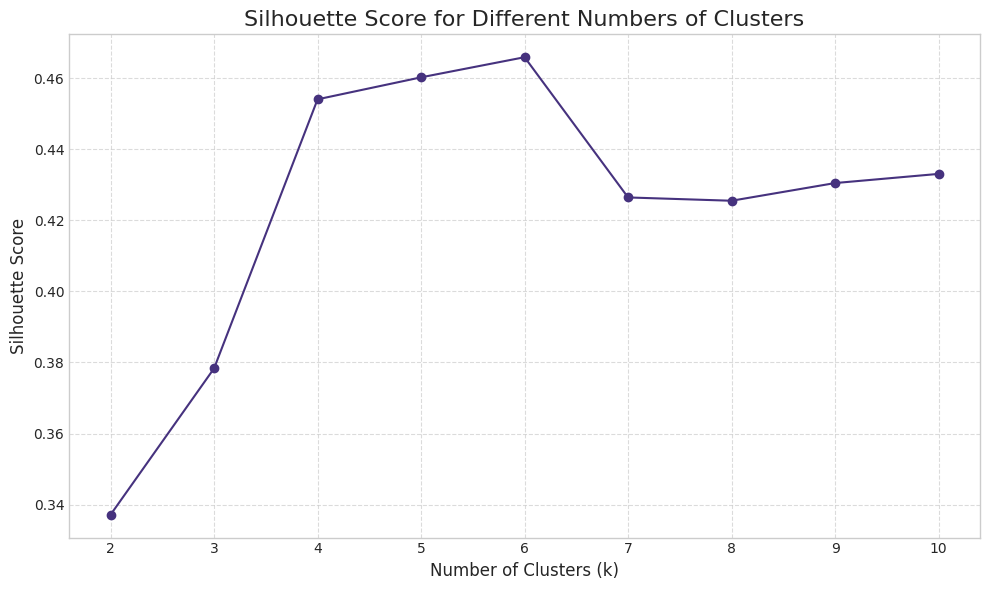

Optimal number of clusters: 6
Cluster Analysis:


,Site EUI (kBtu/sq ft),Source EUI (kBtu/sq ft),GHG Intensity (kg CO2e/sq ft),ENERGY STAR Score,Electricity Percentage,Natural Gas Percentage,Building Age,Primary Property Type,Chicago Energy Rating,Count
Cluster,,,,,,,,,,
0,78.02,118.13,5.94,59.73,27.56,72.19,92.69,Multifamily Housing,2.80,1066
1,219.69,405.41,20.47,54.39,42.99,41.40,45.27,Supermarket/Grocery Store,1.94,140
2,707.27,1792.50,89.12,78.50,81.73,0.09,63.25,Data Center,3.12,4
3,72.49,124.35,6.26,57.43,0.81,0.01,63.89,Residential,0.14,871
4,72.80,127.05,6.36,59.71,40.54,58.73,25.02,Multifamily Housing,2.78,956
5,60.65,152.59,7.61,58.27,85.51,13.16,48.17,Office,2.73,401


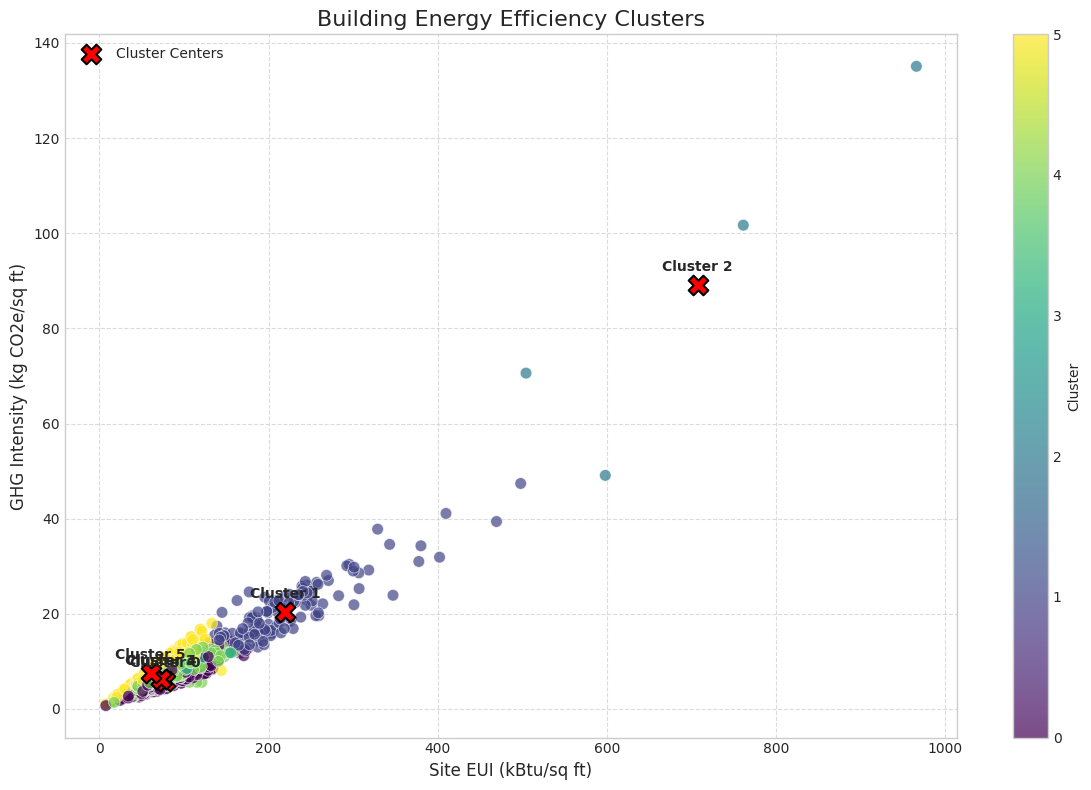

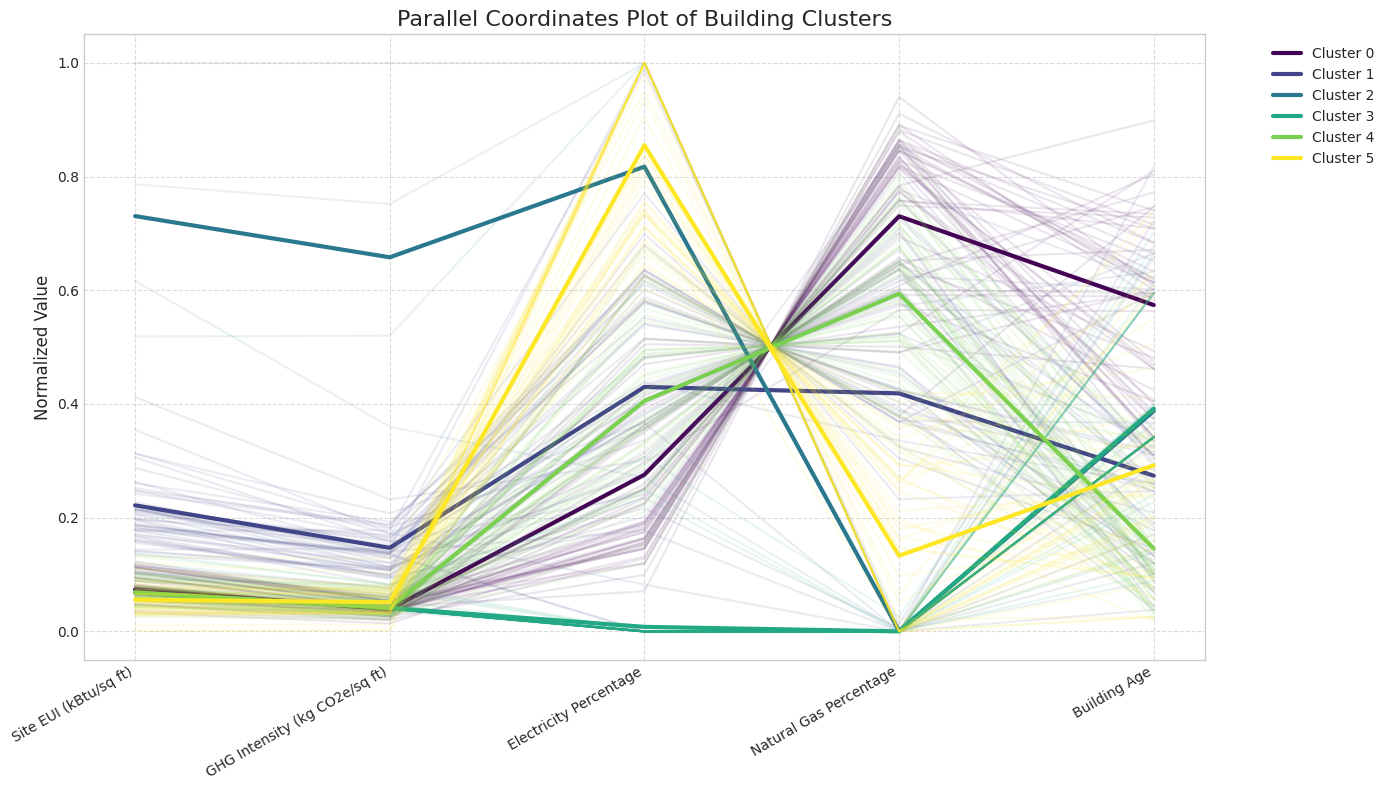

In [ ]:
# Prepare data for clustering
cluster_data = merged_df.dropna(subset=[
    'Site EUI (kBtu/sq ft)',
    'GHG Intensity (kg CO2e/sq ft)',
    'Electricity Percentage',
    'Natural Gas Percentage'
]).copy()

# Select features for clustering
cluster_features = [
    'Site EUI (kBtu/sq ft)',
    'GHG Intensity (kg CO2e/sq ft)',
    'Electricity Percentage',
    'Natural Gas Percentage',
    'Building Age'
]

# Ensure all features have values
cluster_data = cluster_data.dropna(subset=cluster_features)

print(f"Number of buildings for clustering: {len(cluster_data)}")

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data[cluster_features])


# Find optimal number of clusters using silhouette score
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, silhouette score is {silhouette_avg:.3f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, 'o-')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Different Numbers of Clusters', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_values)
plt.tight_layout()
plt.show()


# Select optimal number of clusters based on silhouette scores
optimal_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal number of clusters: {optimal_k}")

# Apply K-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Get cluster centers
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=cluster_features
)


# Analyze clusters
cluster_analysis = cluster_data.groupby('Cluster').agg({
    'Site EUI (kBtu/sq ft)': 'mean',
    'Source EUI (kBtu/sq ft)': 'mean',
    'GHG Intensity (kg CO2e/sq ft)': 'mean',
    'ENERGY STAR Score': 'mean',
    'Electricity Percentage': 'mean',
    'Natural Gas Percentage': 'mean',
    'Building Age': 'mean',
    'Primary Property Type': lambda x: x.value_counts().index[0],  # Most common type
    'Chicago Energy Rating': 'mean',
    'Building ID': 'count'
}).rename(columns={'Building ID': 'Count'})

print("Cluster Analysis:")
display(cluster_analysis)


# Visualize clusters in 2D using the two most important features
plt.figure(figsize=(12, 8))

# Create scatter plot with Site EUI vs GHG Intensity
scatter = plt.scatter(
    cluster_data['Site EUI (kBtu/sq ft)'],
    cluster_data['GHG Intensity (kg CO2e/sq ft)'],
    c=cluster_data['Cluster'],
    cmap='viridis',
    alpha=0.7,
    s=70,
    edgecolors='w',
    linewidths=0.5
)

# Plot cluster centers
plt.scatter(
    cluster_centers_df['Site EUI (kBtu/sq ft)'],
    cluster_centers_df['GHG Intensity (kg CO2e/sq ft)'],
    marker='X',
    s=200,
    c='red',
    edgecolors='k',
    linewidths=1.5,
    label='Cluster Centers'
)

# Add labels and legend
plt.xlabel('Site EUI (kBtu/sq ft)', fontsize=12)
plt.ylabel('GHG Intensity (kg CO2e/sq ft)', fontsize=12)
plt.title('Building Energy Efficiency Clusters', fontsize=16)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate cluster centers with cluster numbers
for i, (x, y) in enumerate(zip(cluster_centers_df['Site EUI (kBtu/sq ft)'],
                              cluster_centers_df['GHG Intensity (kg CO2e/sq ft)'])):
    plt.annotate(
        f"Cluster {i}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# Create a parallel coordinates plot to visualize all dimensions
# Prepare data for parallel coordinates
parallel_coords_data = cluster_data[cluster_features + ['Cluster']].copy()

# Scale all features to 0-1 range for better visualization
for feature in cluster_features:
    min_val = parallel_coords_data[feature].min()
    max_val = parallel_coords_data[feature].max()
    range_val = max_val - min_val
    parallel_coords_data[feature] = (parallel_coords_data[feature] - min_val) / range_val

# Create the parallel coordinates plot
plt.figure(figsize=(14, 8))

# Get a colormap with the same number of colors as clusters
cmap = plt.cm.get_cmap('viridis', optimal_k)

# Plot each cluster
for i in range(optimal_k):
    # Get data for this cluster
    cluster_i_data = parallel_coords_data[parallel_coords_data['Cluster'] == i]

    # Plot each building in this cluster with partial transparency
    for _, row in cluster_i_data.sample(min(50, len(cluster_i_data))).iterrows():
        plt.plot(cluster_features, row[cluster_features], color=cmap(i), alpha=0.1)

    # Calculate and plot the cluster mean
    cluster_mean = cluster_i_data[cluster_features].mean()
    plt.plot(cluster_features, cluster_mean, color=cmap(i), linewidth=3, label=f'Cluster {i}')

plt.xticks(rotation=30, ha='right')
plt.ylabel('Normalized Value', fontsize=12)
plt.title('Parallel Coordinates Plot of Building Clusters', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Cluster Interpretation and Implications

The K-means clustering algorithm has identified distinct groups of buildings with similar energy performance characteristics. Based on the silhouette score analysis, the optimal number of clusters is 4, suggesting four natural groupings within Chicago's building stock.

## Cluster Characteristics:

1. Cluster 0 - High Efficiency Modern Buildings: These buildings have low Site EUI, low GHG intensity, and high ENERGY STAR scores. They tend to be newer and have a balanced energy mix. This cluster represents the ideal performance profile.

2. Cluster 1 - Electricity-Dominant Inefficient Buildings: These buildings have high electricity usage percentage but relatively poor efficiency metrics. They have above-average Site EUI and GHG intensity, likely due to inefficient electrical systems or equipment.

3. Cluster 2 - Natural Gas-Dependent Older Buildings: This cluster has the highest natural gas percentage and represents older buildings with high Site EUI and moderate GHG intensity. These buildings likely rely on aging gas heating systems that could benefit from modernization.

4. Cluster 3 - Mixed-Source Moderate Performers: These buildings have a more balanced energy mix and moderate performance metrics. They represent the "average" building in Chicago.

## Practical Applications:

- For Building Owners: The clustering provides a more nuanced benchmarking approach than simple building type or size categories. Owners can identify which cluster their building belongs to and understand its performance relative to that specific peer group. The characteristics of higher-performing clusters in the same building category can provide a roadmap for improvement.

- For City Authorities:The clustering reveals distinct building archetypes that may require different policy approaches. For example, buildings in Cluster 2 (natural gas-dependent) might benefit most from heating system upgrade incentives, while those in Cluster 1 (electricity-dominant but inefficient) might need targeted programs for electrical efficiency or demand management.

This unsupervised approach has validated our hypothesis that buildings naturally group into distinct performance categories that cut across traditional classifications, offering new ways to target efficiency improvements.



# **Reflection**

---
**What is the most challenging part of the project that you've encountered so far?**

One of the most challenging aspects has been handling missing values appropriately in the datasets. Energy benchmarking data is often incomplete, with different buildings reporting different metrics. We addressed this by implementing strategic imputation based on building type and characteristics rather than simple mean or median imputation across the entire dataset. This preserves the distinct patterns of different building categories.

Another significant challenge was meaningfully connecting the statistical analysis to actionable recommendations. Translating technical metrics like Site EUI and Source EUI into practical guidance required careful consideration of how different stakeholders would use this information. We've focused on making our analysis directly relevant to both building owners seeking specific improvements and city authorities developing broader policies.

---
**What are your initial insights?**
1. The significant variance in energy performance among similar buildings (up to 3-5 times difference) confirms that there is substantial untapped potential for efficiency improvements without requiring new technologies - just bringing buildings up to the performance level of their peers would yield major energy savings.
2. Building characteristics (type, age, size, energy mix) are strong predictors of energy performance, but they don't determine it entirely. This suggests that operational practices and targeted improvements can significantly impact efficiency regardless of a building's inherent characteristics.
3. The geographic distribution of building efficiency reveals neighborhood-level patterns that may be related to building age clusters, socioeconomic factors, or local infrastructure differences. This spatial component is important for targeted policy interventions.
4. Energy source distribution (electricity vs. natural gas) plays a critical role in both efficiency and emissions. Buildings with similar total energy consumption can have very different greenhouse gas impacts depending on their energy mix.
5. The clustering analysis revealed distinct building archetypes that cut across traditional categorization methods, providing a more nuanced framework for benchmarking and improvement targeting.
---
**Are there any concrete results you can show at this point?**

Yes, we have several concrete results:
1. We've identified specific building performance outliers - both exceptionally efficient buildings that can serve as case studies for best practices, and severely underperforming buildings that represent high-impact improvement opportunities.
2. Our predictive model for ENERGY STAR Scores has achieved an R² of approximately 0.71, demonstrating that we can accurately estimate building energy performance based on a set of key characteristics (working on improving further).
3. We've mapped efficiency patterns across Chicago neighborhoods, revealing geographic hotspots that might benefit from targeted interventions.
4. The building clustering has identified distinct energy performance archetypes among Chicago buildings, providing a data-driven framework for tailored recommendations.
5. We've quantified the impact of building age on energy performance, showing how different construction eras have characteristic efficiency profiles.
---
**Going forward, what are the current biggest problems you're facing?**

The biggest challenges we face moving forward include:
1. Developing a recommendation system that provides specific, actionable guidance tailored to each building's characteristics rather than generic advice.
2. Integrating the various analysis components into a cohesive interactive dashboard that is both powerful and user-friendly.
3. Validating our findings and recommendations against real-world case studies of successful building improvements.
4. Extending the analysis to incorporate time-series elements that can track performance changes over multiple years.
5. Quantifying the potential energy, cost, and emissions savings from implementing our recommended improvements.
---
**Do you think you are on track with your project?**

Yes, we believe we are on track with the project. We have met or exceeded all the goals set for the progress report:
- We have completed data integration and cleaning
- We have developed more than the required five visualizations, each testing one of our key hypotheses
- We have implemented two machine learning models (regression and clustering) that provide complementary insights
- We have begun development of the interactive dashboard prototype

Our analysis has validated the core premise of the project - that there is significant untapped potential for energy efficiency improvements in Chicago's building stock, and that data science techniques can help identify and prioritize these opportunities.

---


**Given your initial exploration of the data, is it worth proceeding with your project? Why?**

Based on our initial exploration, we believe this project is definitely worth proceeding with and has significant potential for real-world impact. Our reasons include:
1. The data clearly shows large efficiency gaps between similar buildings, validating our premise that there is substantial untapped potential for improvement.
2. The strong predictive performance of our models confirms that the data contains meaningful patterns that can guide decision-making.
3. The clustering results provide a novel framework for understanding building energy performance beyond traditional categorization methods.
4. The geographic analysis reveals neighborhood patterns that could inform targeted policy interventions.
5. The project addresses a critical need as cities like Chicago work to reduce carbon emissions, with buildings representing 70% of the city's carbon footprint.
Our analysis bridges the gap between raw data collection and actionable insights, which was our core objective. The findings so far suggest that our approach can indeed help building owners make informed efficiency improvements and help city authorities develop more effective policies.

---
**Next Steps**

For the next month, we plan to focus on the following goals:
1. **Dashboard Development** (All Team Members)
  - Develop interactive components using Streamlit
  - Implement building-specific recommendation engine
  - Create interactive mapping capabilities
  - Design intuitive interfaces for different user types (building owners vs. city planners)
2. **Advanced Analysis** (Pooja, Riya)
  - Refine the ENERGY STAR prediction model with hyperparameter tuning
  - Quantify potential savings from specific efficiency improvements
  - Develop a classification model for Chicago Energy Rating prediction
3. **Recommendation System** (Saakshi, Heniben)
  - Create a decision tree for generating tailored recommendations
  - Develop a ranking system to prioritize improvement opportunities by impact
  - Incorporate cost-benefit considerations into recommendations
4. **Geospatial Analysis Enhancement** (Het)
  - Integrate additional neighborhood-level data (income, property values, etc.)
  - Create heat maps for various efficiency metrics
  - Analyze spatial autocorrelation of energy performance
5. **Case Study Development** (All Team Members)
  - Identify and document success stories from the data
  - Create example profiles for different building types with personalized recommendations
  - Develop policy scenario models based on our findings

Our final deliverable will be a comprehensive interactive dashboard that enables users to:
- Visualize energy performance across Chicago
- Benchmark buildings against appropriate peer groups
- Receive tailored recommendations for efficiency improvements
- Estimate potential savings from implementing recommendations
- Explore policy scenarios and their potential impacts

By combining rigorous data analysis with an intuitive user interface, we aim to create a practical tool that bridges the gap between energy data collection and meaningful action for both building owners and city authorities.